# Example-14: Joined spectrum

In [1]:
# Import

import numpy
import torch
import nufft
import yaml

import sys
sys.path.append('..')

from harmonica.util import LENGTH
from harmonica.statistics import weighted_mean, weighted_variance
from harmonica.window import Window
from harmonica.data import Data
from harmonica.frequency import Frequency
from harmonica.filter import Filter

import matplotlib.pyplot as plt

torch.set_printoptions(precision=12, sci_mode=True)
print(torch.cuda.is_available())
print(torch.get_num_threads())

False
8


In [2]:
# Set data type and device

dtype = torch.float64
device = torch.device('cpu')

Window(4096, 'cosine_window', 1.0)
Data(54, Window(4096, 'cosine_window', 1.0))
Frequency(Data(54, Window(4096, 'cosine_window', 1.0)), f_range=(0.0, 0.5))


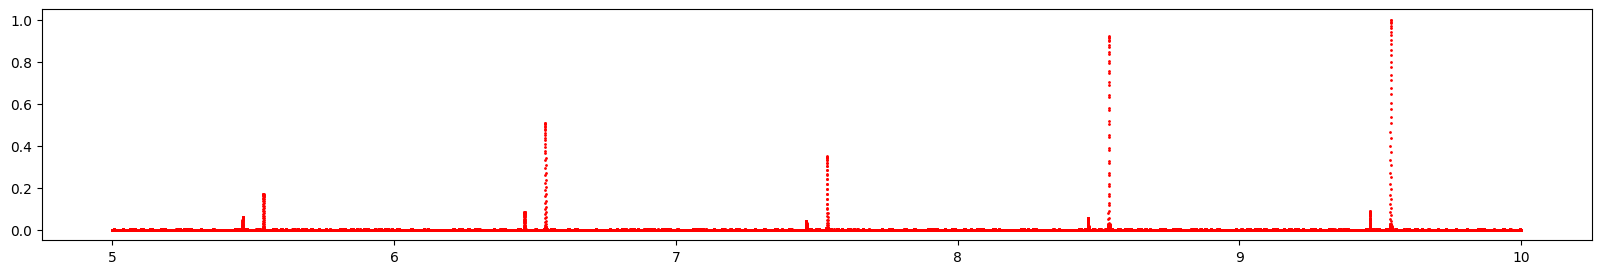

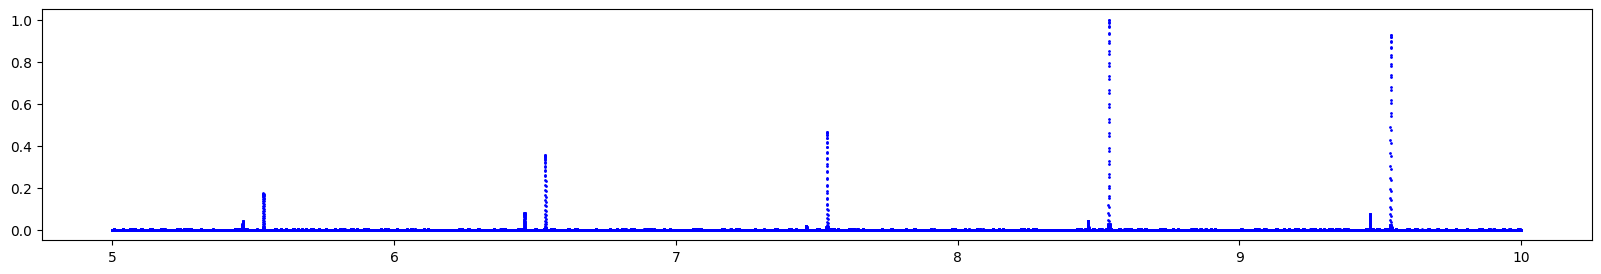

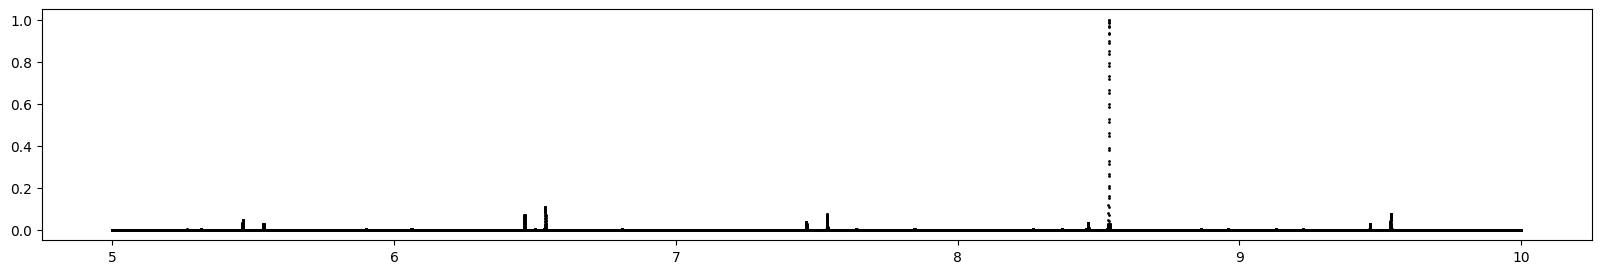

In [3]:
# Load model data

with open('../config.yaml', 'r') as stream:
    config = yaml.safe_load(stream)
    config = {key: config[key] for key in sorted(config.keys(), key=lambda name: config[name]['TIME'])}

# Set normalized positions (used as locations with NUFFT)

position = numpy.array([value['TIME'] for key, value in config.items() if value['TYPE'] == 'MONITOR'])/LENGTH

# Set normalized accumulated phase advance between given monitor location and the next monitor location (used as locations with NUFFT)

phase = numpy.array([value['FX'] for key, value in config.items() if value['TYPE'] == 'MONITOR' or key == 'TAIL'])
*_, tune = phase
phase = numpy.diff(phase)
phase = numpy.cumsum(phase)/tune
start, *_ = phase
phase = phase - start

# Set window

w = Window(4096, name='cosine_window', order=1.0, dtype=dtype, device=device)
print(w)

# Load TbT data from file and add noise

d = Data.from_file(54, w, '../virtual_tbt.npy')
s = 1.0E-4*torch.ones(54, dtype=dtype, device=device)
d.add_noise(s)
print(d)

# Initialize Frequency instance

f = Frequency(d)
print(f)

# Compute & plot mixed spectrum

f_range=(5.0, 10.0)
s1 = f.compute_joined_spectrum(length=1024, normalize=True, f_range=f_range, name='cosine_window', order=1.0, position=None)
s2 = f.compute_joined_spectrum(length=1024, normalize=True, f_range=f_range, name='cosine_window', order=1.0, position=position)
s3 = f.compute_joined_spectrum(length=1024, normalize=True, f_range=f_range, name='cosine_window', order=1.0, position=phase)
plt.figure(figsize=(20, 3))
plt.scatter(*s1, c='red', s=1)
plt.show()
plt.figure(figsize=(20, 3))
plt.scatter(*s2, c='blue', s=1)
plt.show()
plt.figure(figsize=(20, 3))
plt.scatter(*s3, c='black', s=1)
plt.show()

# Clean

del w
del d
del f
del s1, s2, s3
if device != torch.device('cpu'):
    torch.cuda.synchronize()
    torch.cuda.empty_cache()
    
# s1 -- (red)   pre-normalized mixed signal treated as if it is uniformly sampled
# s2 -- (blue)  pre-normalized mixed signal and type-iii nufft with BPM normalized position as location
# s3 -- (black) pre-normalized mixed signal and type-iii nufft with BPM normalized accumulated phase as location

# As it can be seen, here s1 gives wrong integer part (location of peak with maximum amplitude)
# But this is not always the case, filtering by beta function or phase can resolve this

# Normalization is performed before to mixing to make mixed signal closer to a stationary one
# Another option to reduce the effect of signal being non-stationary is to scale it with beta function
# Or to remove BPMs where amplitudes are not close enough, e.g. near IP